# Group 5: Model Explainability & Retention Strategy (Master Notebook)

**Customer Churn Prediction & Business Intelligence System**

**Team Size: 3 Members**

**Main Objective:** Explain why customers are likely to churn and convert model findings into practical, ROI-positive retention actions.

---

### Workflow Outline:
1. **Part 1 (Member 1)**: Global Feature Importance, Standardized Coefficients, Odds Ratios, and Global SHAP Summary.
2. **Part 2 (Member 2)**: Local Instance Explanations, Customer Risk Stratification (Low, Medium, High), and High-Risk Factor Profiling.
3. **Part 3 (Member 3)**: Churn Driver -> Customer Segment -> Recommended Action Matrix, Campaign ROI Modeling, and Business Playbook.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CURRENT_DIR = Path.cwd()
SRC_DIR = CURRENT_DIR / "src" if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent / "src"
sys.path.insert(0, str(SRC_DIR))

from explainers import ChurnModelExplainer
from risk_profiler import CustomerRiskProfiler
from retention_engine import RetentionStrategyEngine

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

## 1. Load Dataset & Train Final Pipeline

In [2]:
DATA_PATH = Path("../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")

df = pd.read_csv(DATA_PATH)

CORE_FEATURES = [
    "Senior Citizen", "Partner", "Dependents", "Tenure Months", "Multiple Lines",
    "Internet Service", "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies", "Contract",
    "Paperless Billing", "Payment Method", "Monthly Charges", "Total Charges",
    "Fiber_Monthly_Risk", "New_High_Spend", "New_Monthly_Customer", "Security_Tech_Bundle"
]
TARGET = "Churn Value"

X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("categorical", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)
    ],
    remainder="drop"
)

clf = LogisticRegression(C=0.1, class_weight="balanced", solver="lbfgs", max_iter=2000, random_state=42)
pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
pipeline.fit(X, y)

print("Deployment Pipeline successfully fitted on", len(X), "customer records.")

Deployment Pipeline successfully fitted on 7043 customer records.


## Part 1: Global Feature Importance & SHAP Analysis (Member 1)

Top 10 Global Features by Odds Ratio Impact:
                        Feature  Coefficient  Absolute_Coefficient  Odds_Ratio  Odds_Multiplier_Pct                      Direction  Rank
0           Internet Service_No    -0.990285              0.990285    0.371471           -62.852928      Protector (Reduces Churn)     1
1  Internet Service_Fiber optic     0.914521              0.914521    2.495580           149.558008  Accelerator (Increases Churn)     2
2             Contract_Two year    -0.735056              0.735056    0.479478           -52.052157      Protector (Reduces Churn)     3
3       Contract_Month-to-month     0.705968              0.705968    2.025807           102.580747  Accelerator (Increases Churn)     4
4                 Tenure Months    -0.655117              0.655117    0.519381           -48.061862      Protector (Reduces Churn)     5
5                    Dependents    -0.638007              0.638007    0.528344           -47.165564      Protector (Reduces Churn)   

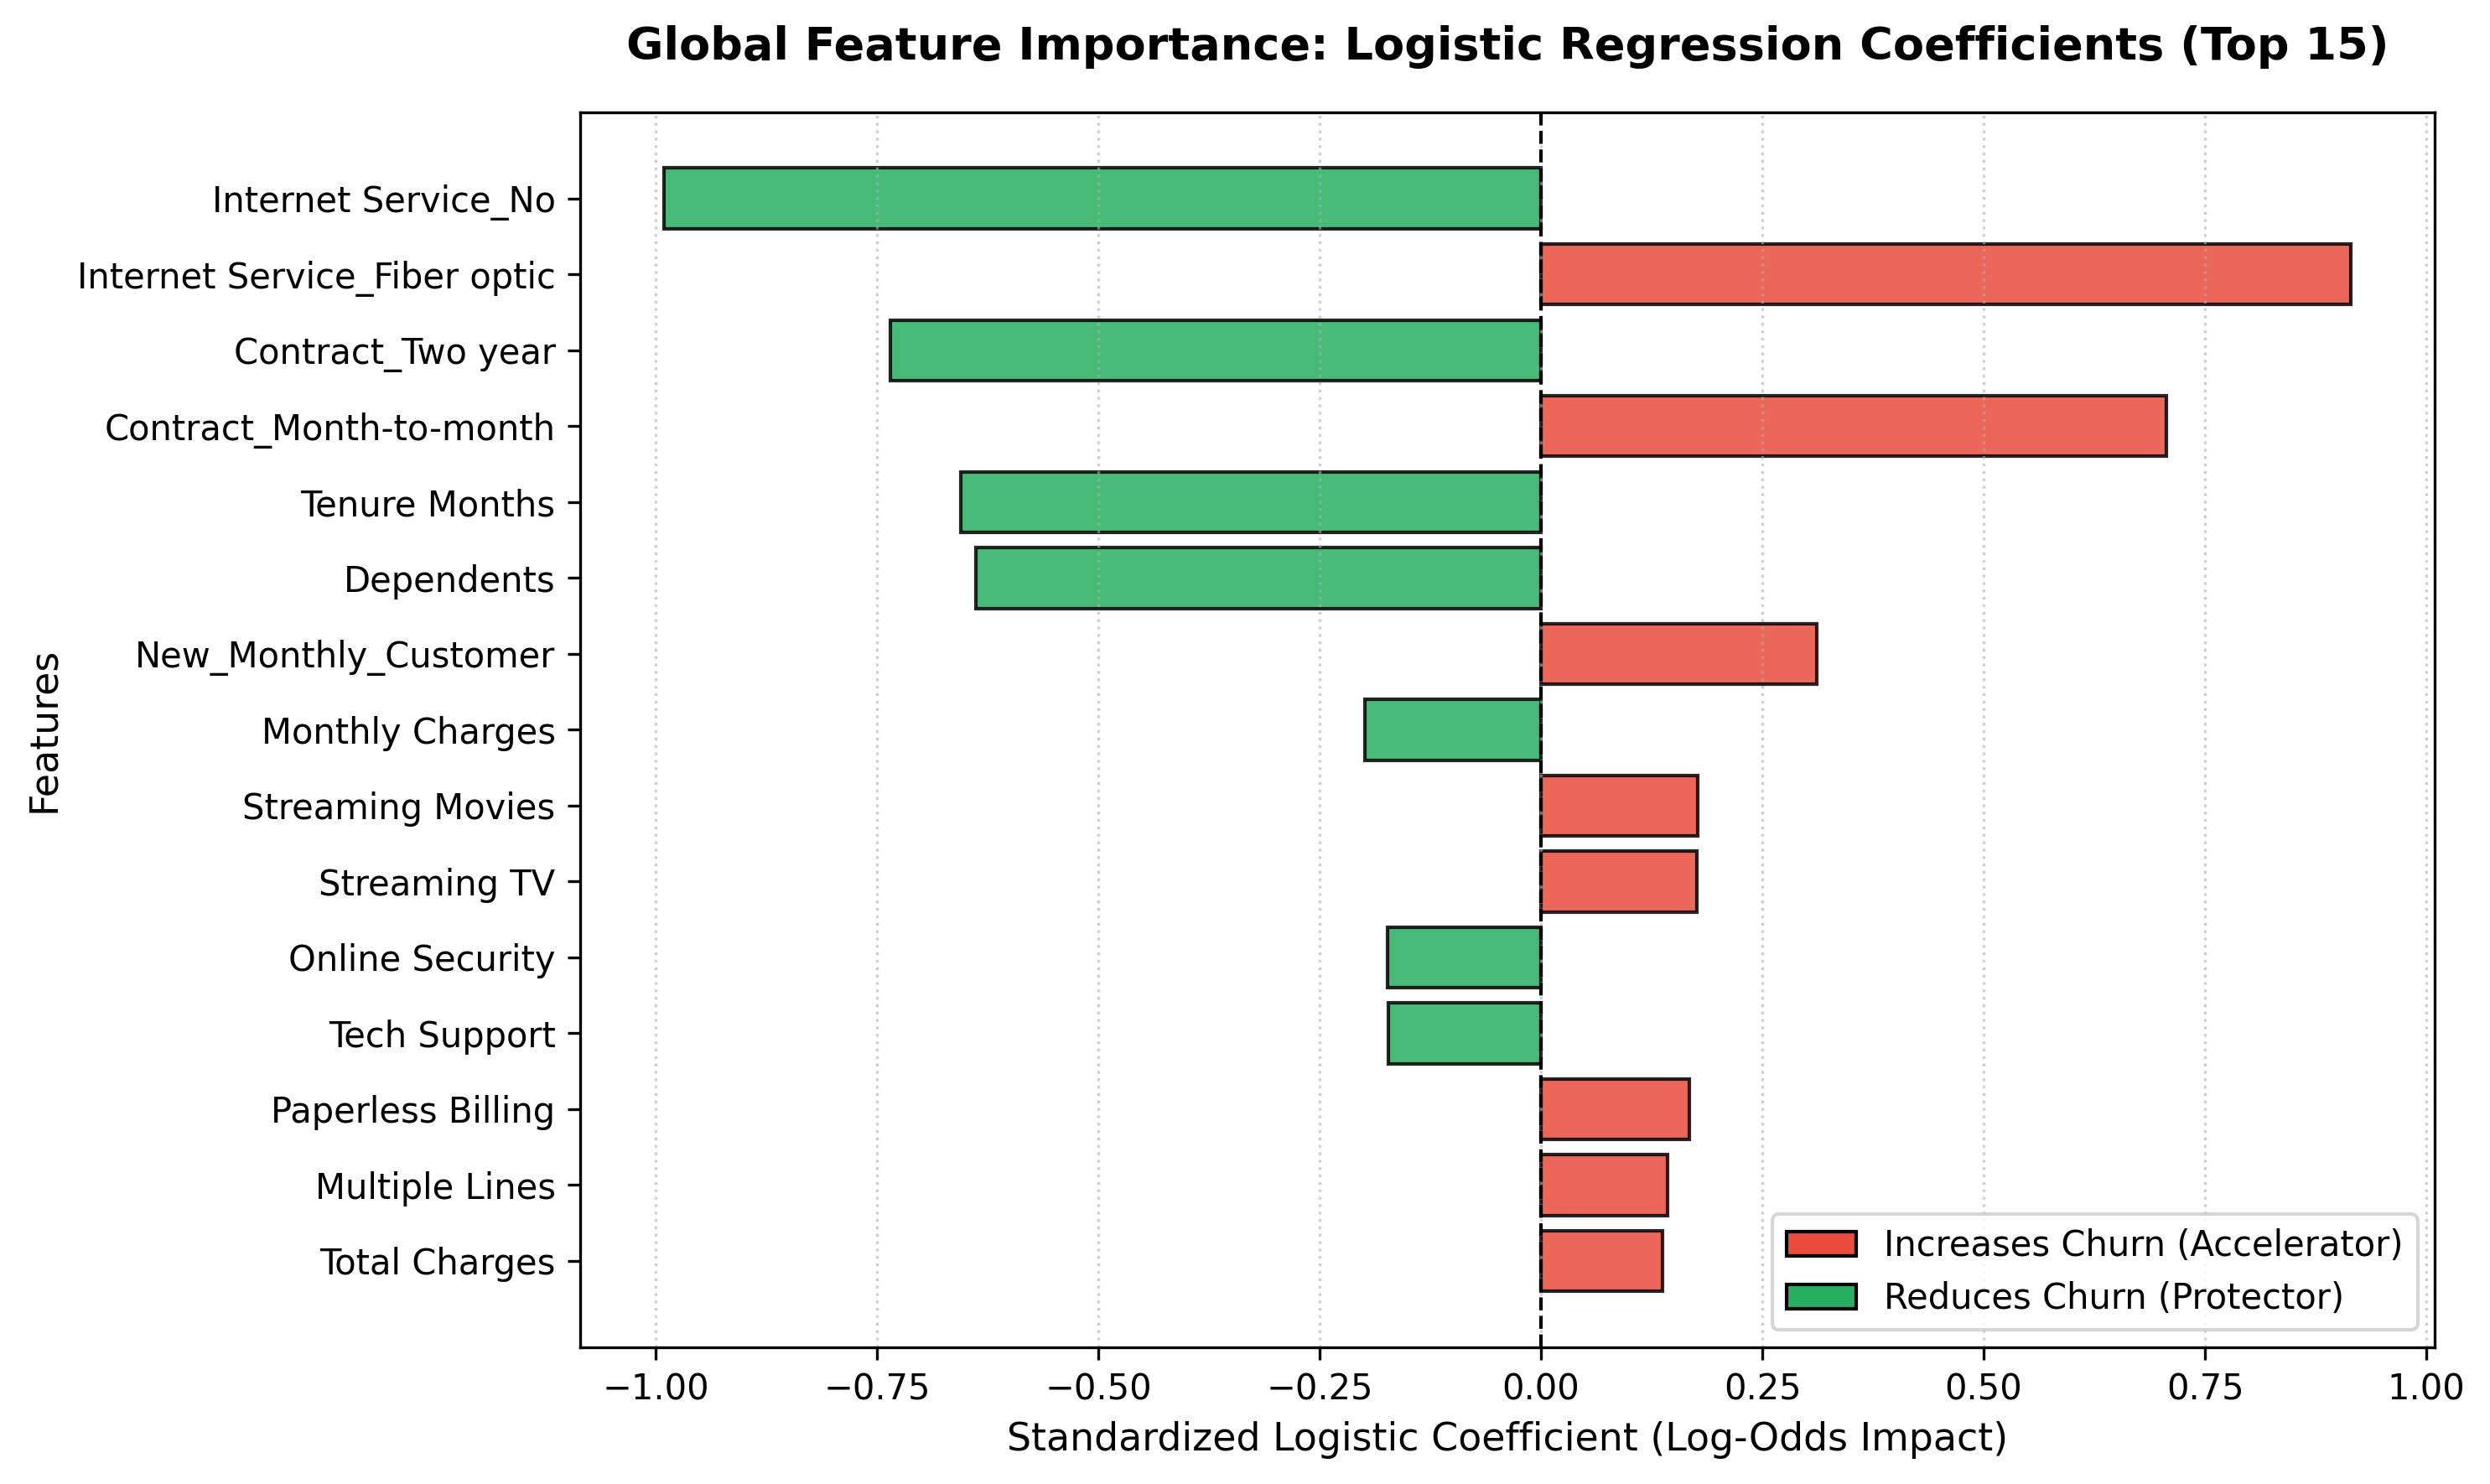

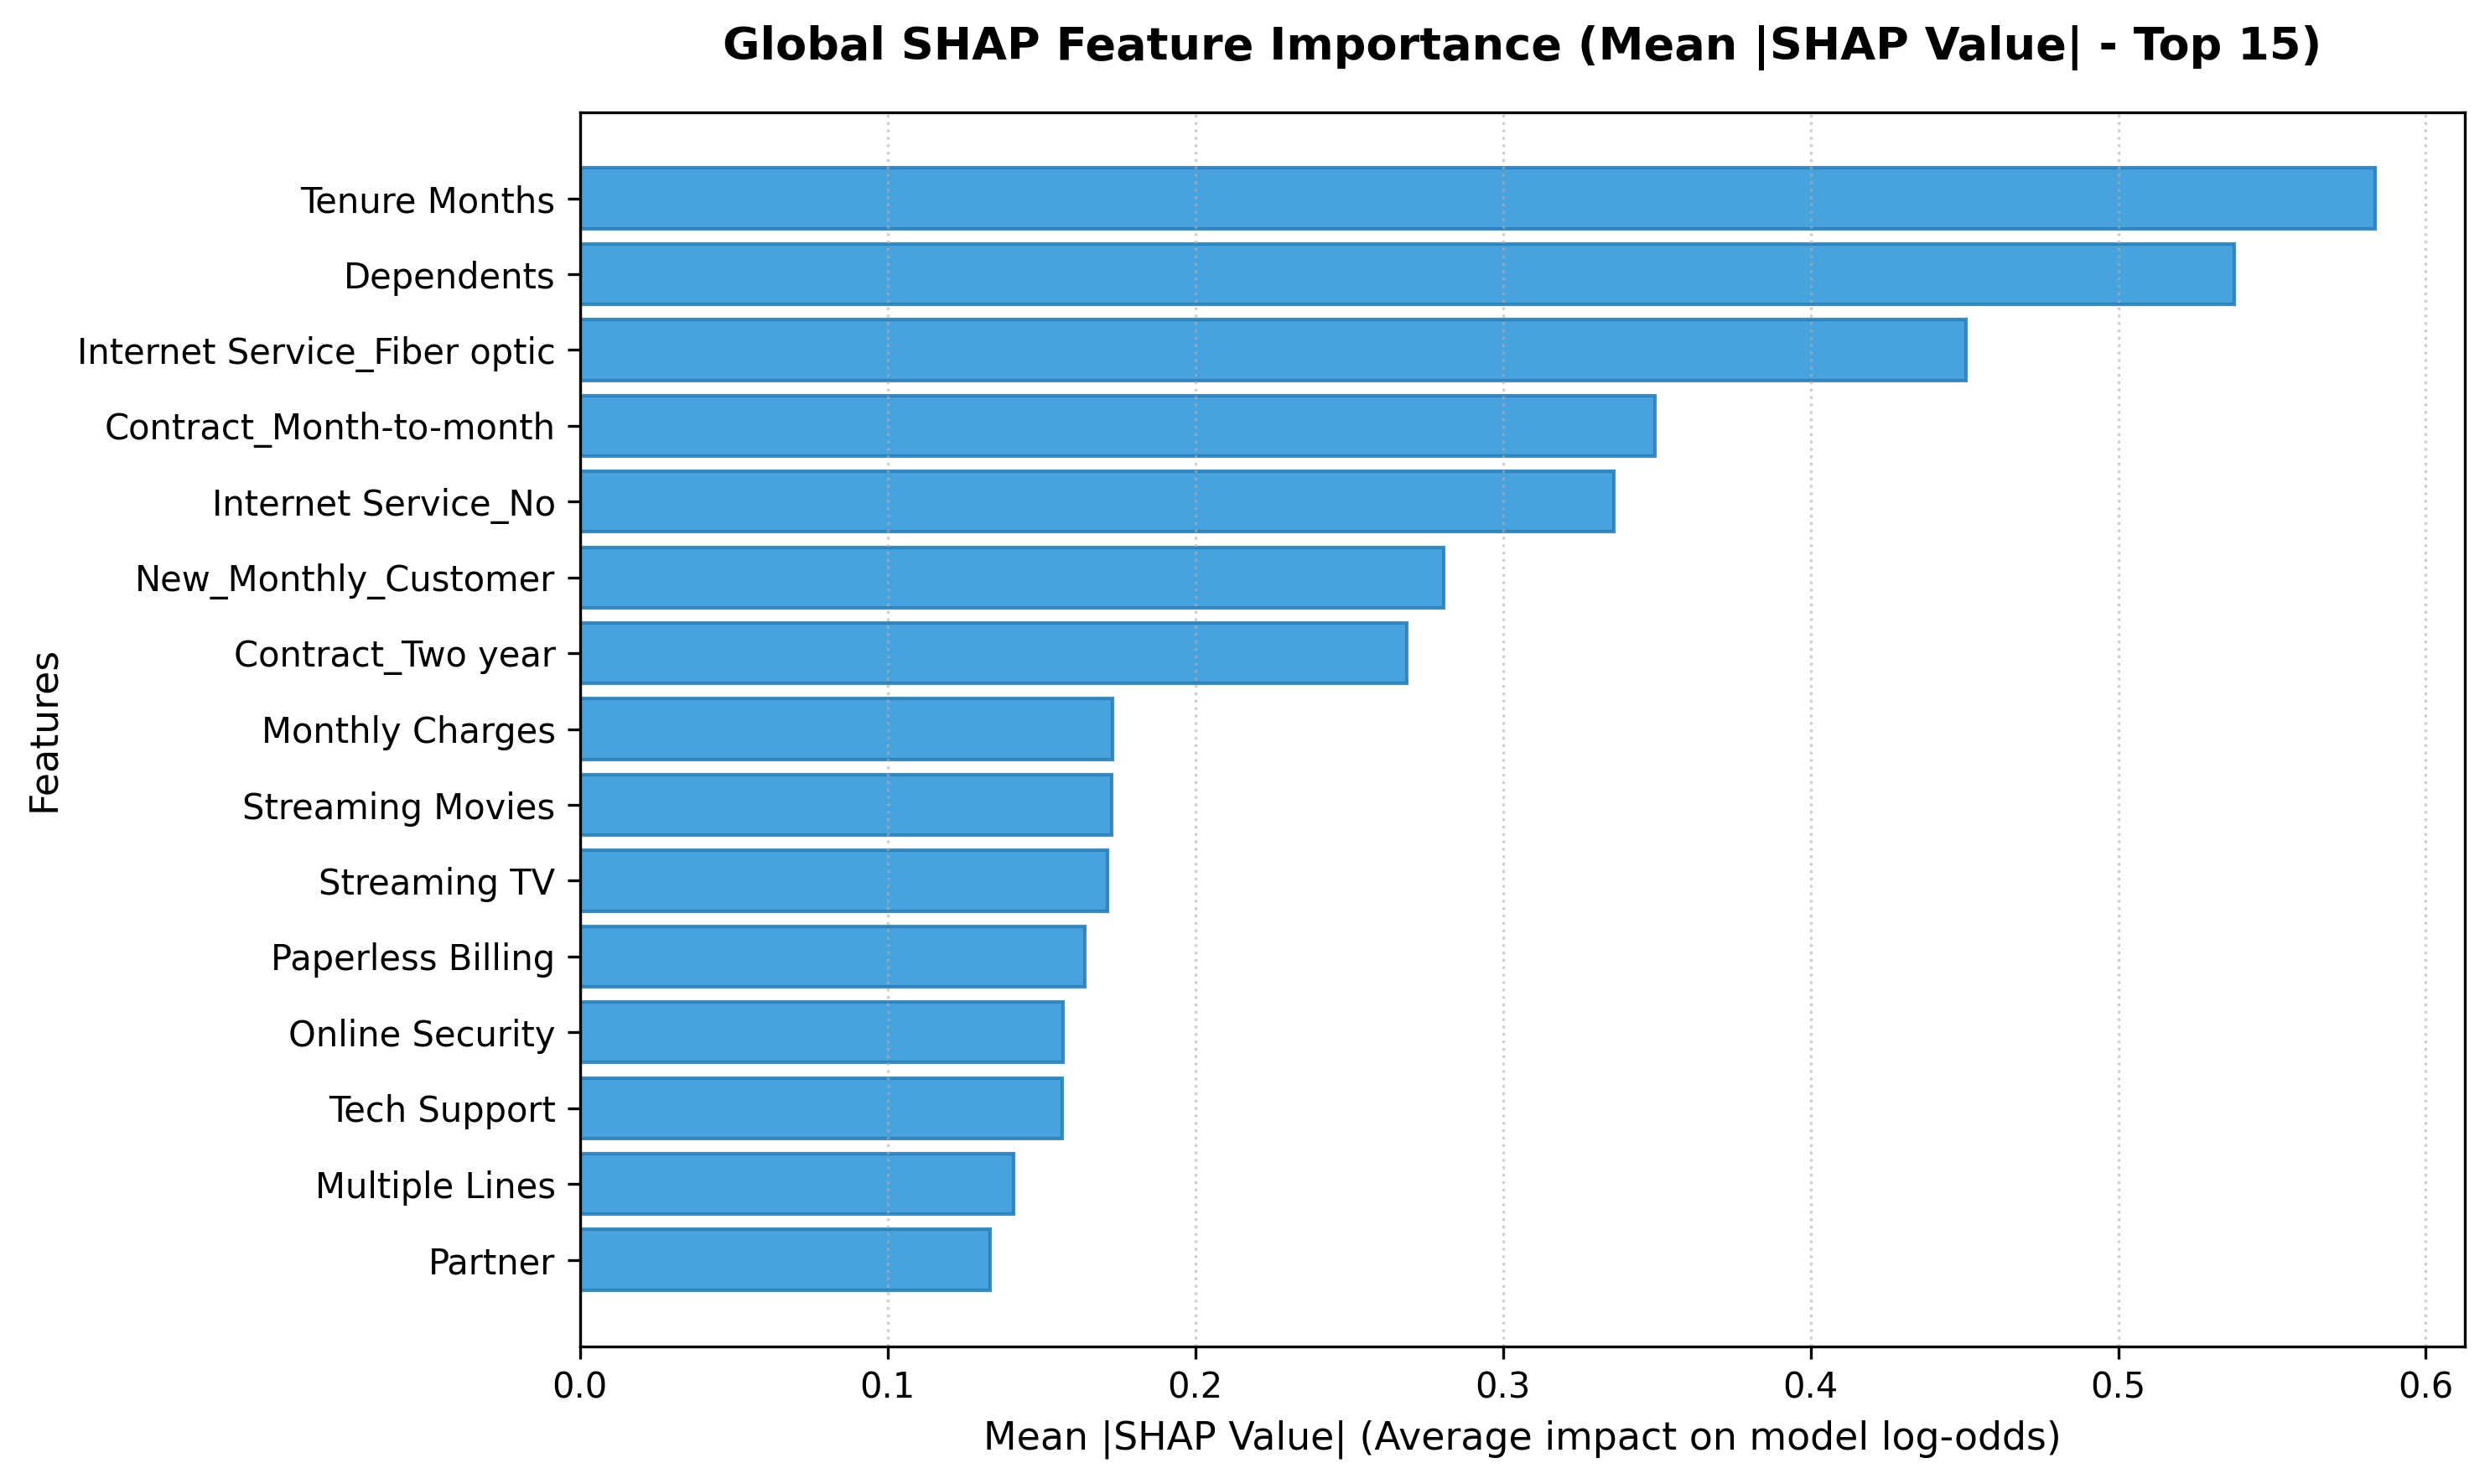

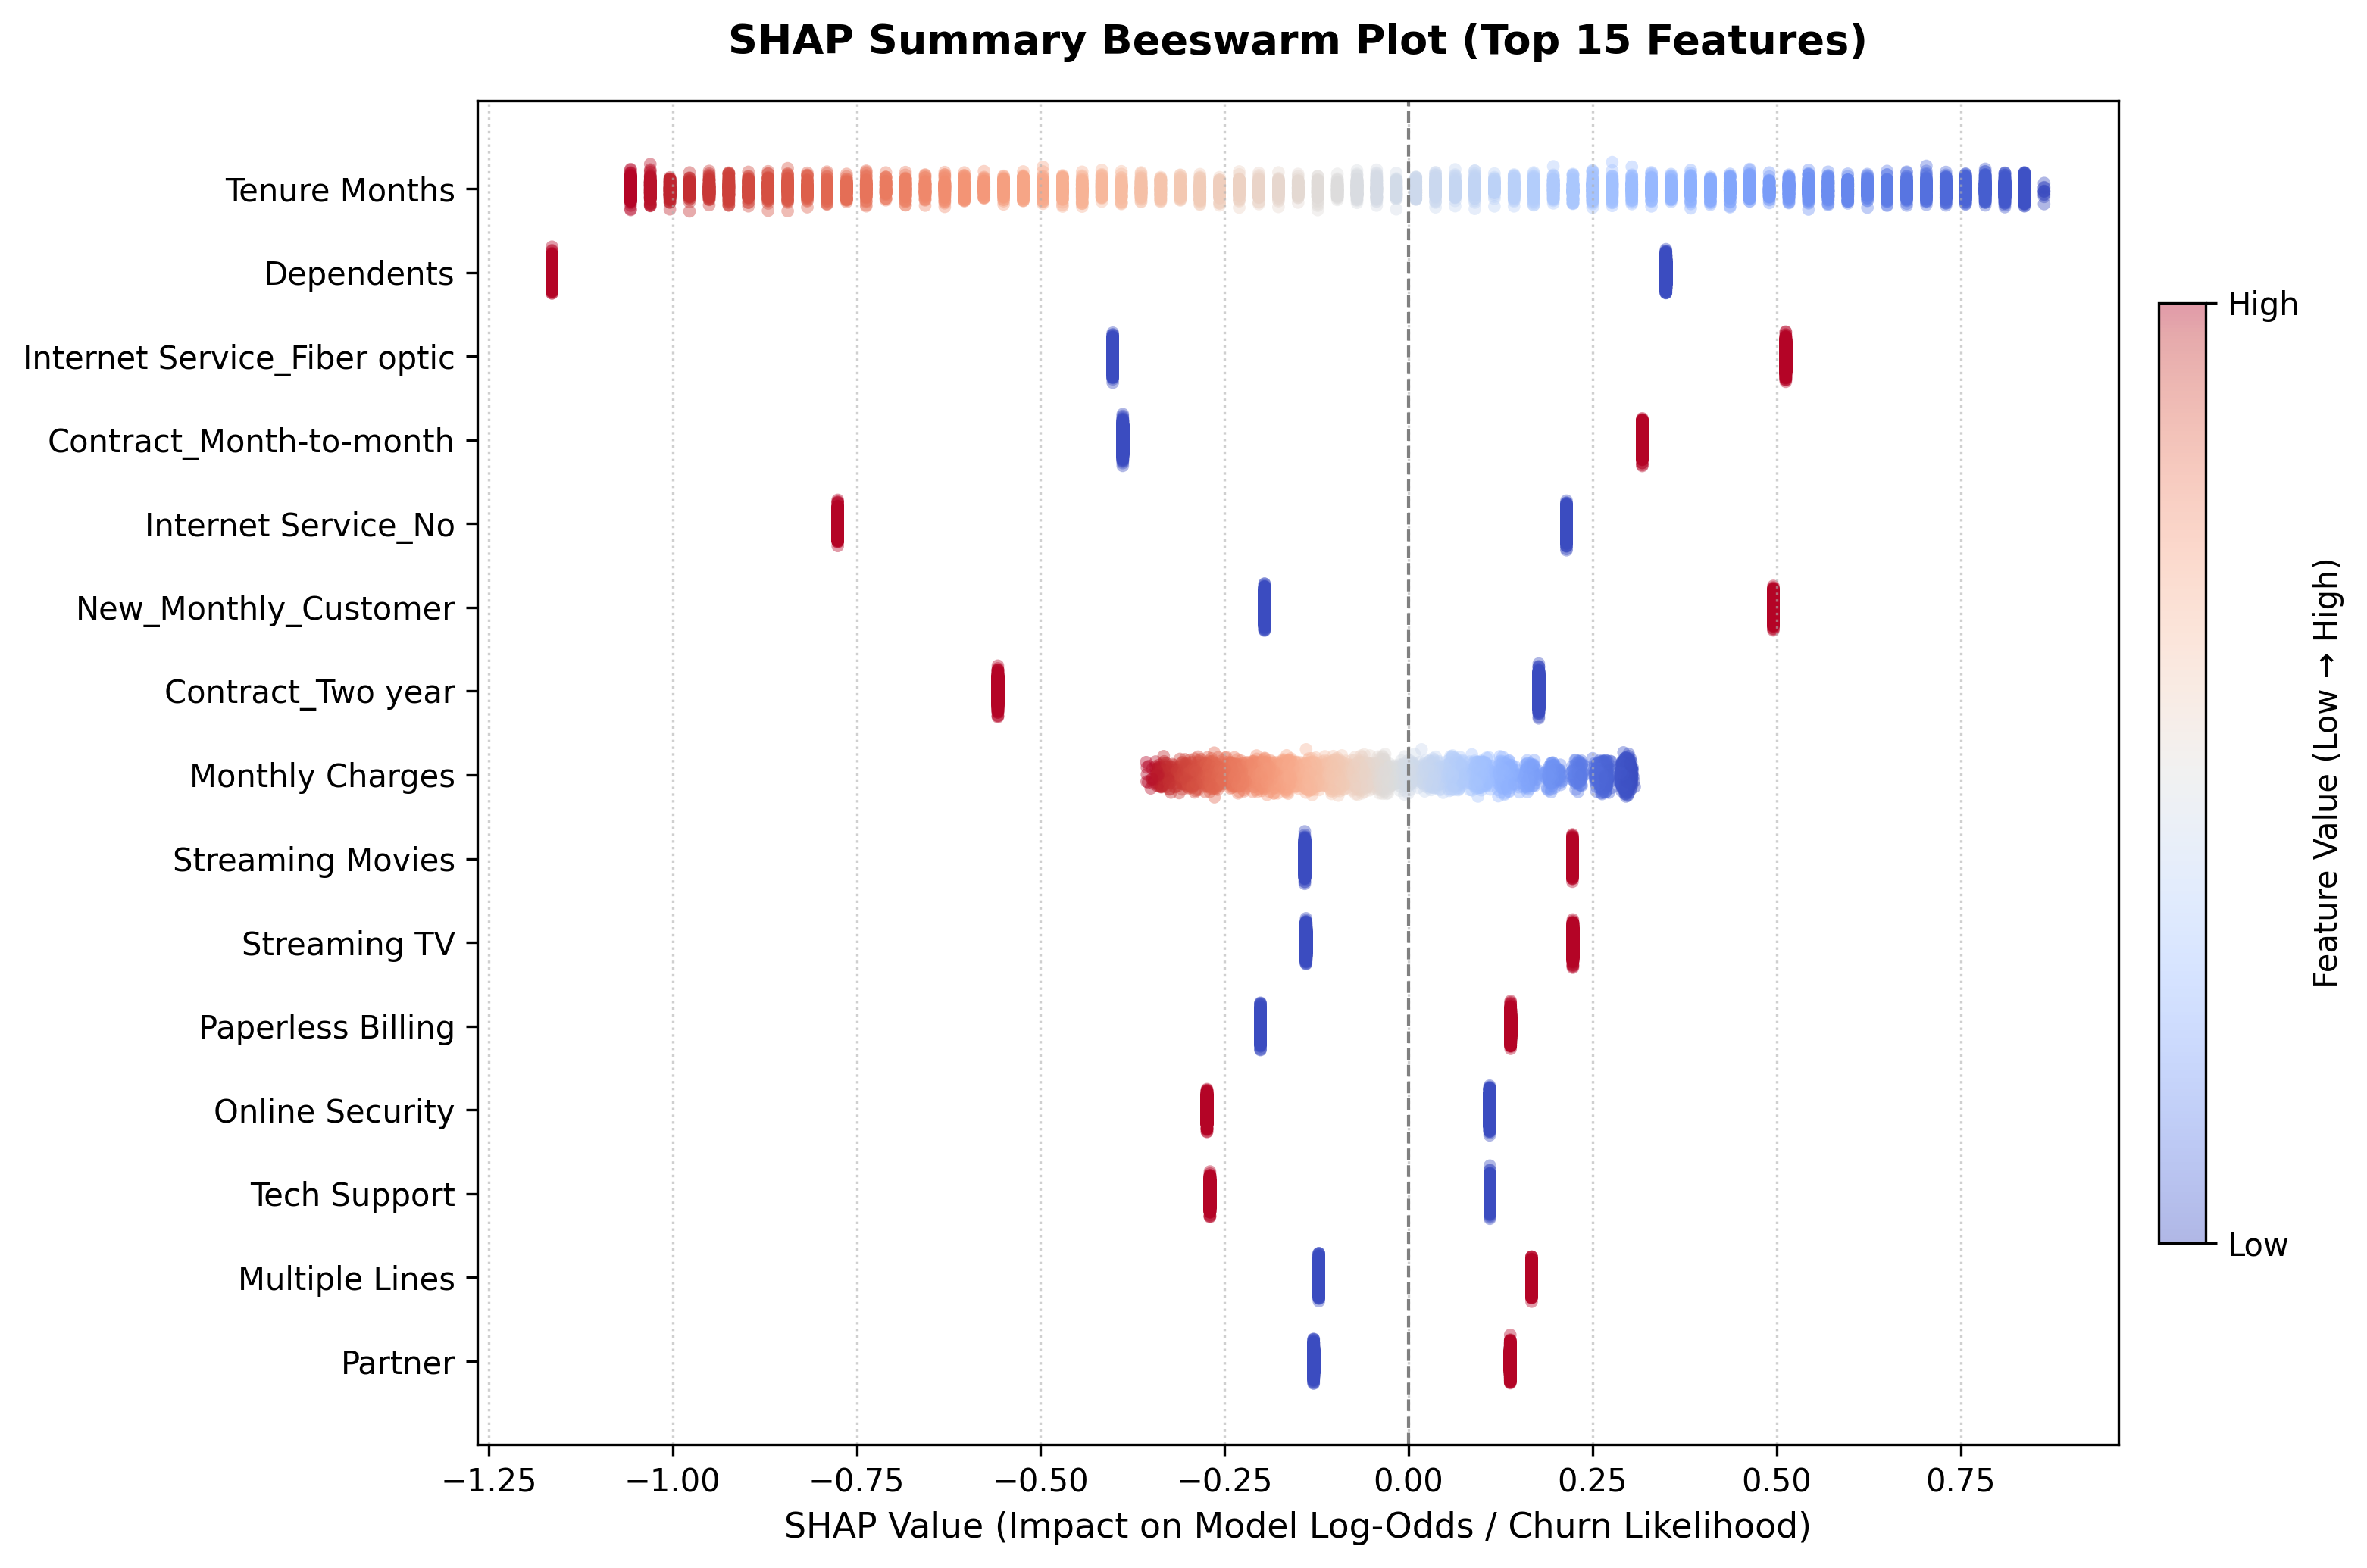

In [3]:
explainer = ChurnModelExplainer(pipeline, feature_names=CORE_FEATURES, background_data=X)

df_global_imp = explainer.compute_global_feature_importance()
print("Top 10 Global Features by Odds Ratio Impact:")
print(df_global_imp.head(10).to_string())

explainer.plot_feature_importance(top_n=15)
explainer.plot_shap_summary_bar(X, top_n=15)
explainer.plot_shap_beeswarm(X, top_n=15)

## Part 2: Local Explanations & Customer Risk Stratification (Member 2)

Customer Risk Tier Distribution:
  Risk_Category  Customer_Count  Mean_Churn_Prob  Min_Churn_Prob  Max_Churn_Prob  Percentage  Avg_Monthly_Charges  Avg_Tenure_Months  Avg_Total_Charges  Actual_Churn_Rate
0     High Risk            2328            78.35             0.6            0.96       33.05                77.04              14.34            1270.38              58.25
1      Low Risk            3217            11.30             0.0            0.30       45.68                55.75              47.00            2951.87               4.54
2   Medium Risk            1498            45.92             0.3            0.60       21.27                65.03              28.99            2404.92              24.50


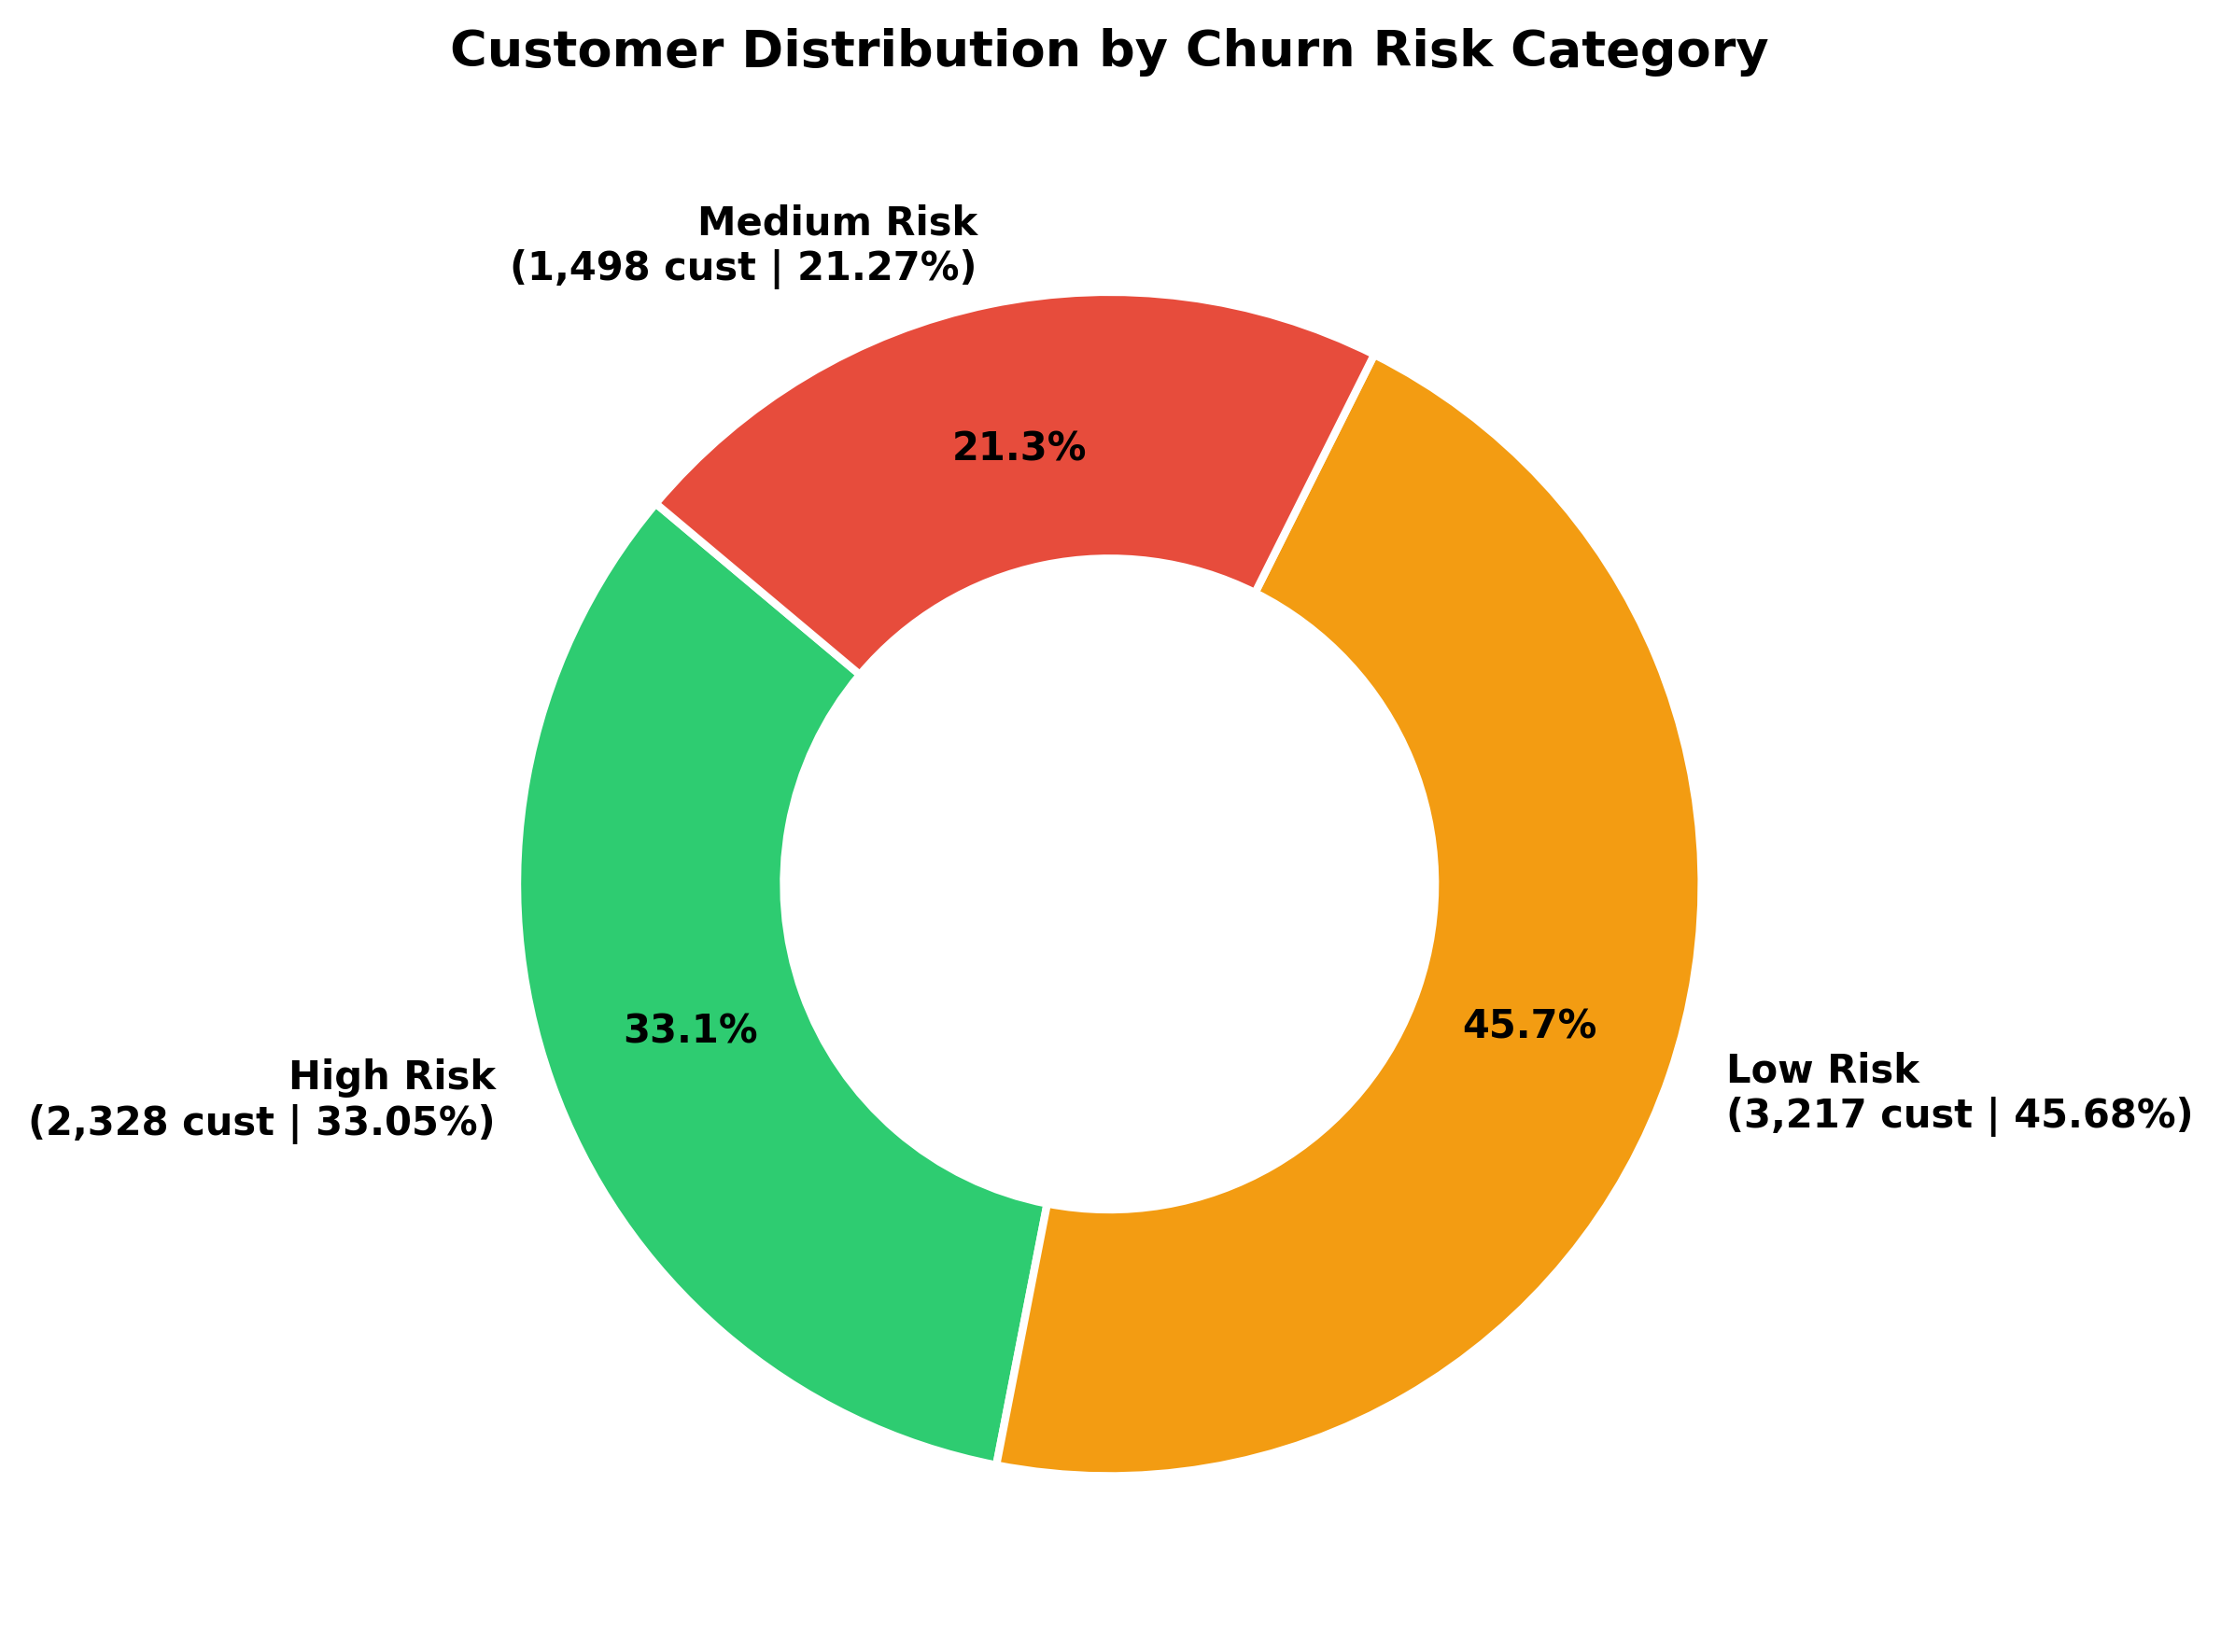

Top Factors Driving High-Risk Customer Predictions:
                         Driver  Primary_Count  Total_Occurrences_In_Top3  High_Risk_Prevalence_Pct
0  Internet Service_Fiber optic          810.0                       1743                     74.87
1                 Tenure Months         1500.0                       1726                     74.14
2                    Dependents           18.0                       1437                     61.73
3          New_Monthly_Customer            0.0                       1422                     61.08
4       Contract_Month-to-month            0.0                        624                     26.80
5                  Streaming TV            0.0                         27                      1.16
6                 Total Charges            0.0                          3                      0.13
7           Internet Service_No            0.0                          1                      0.04
8              Streaming Movies            0.0  

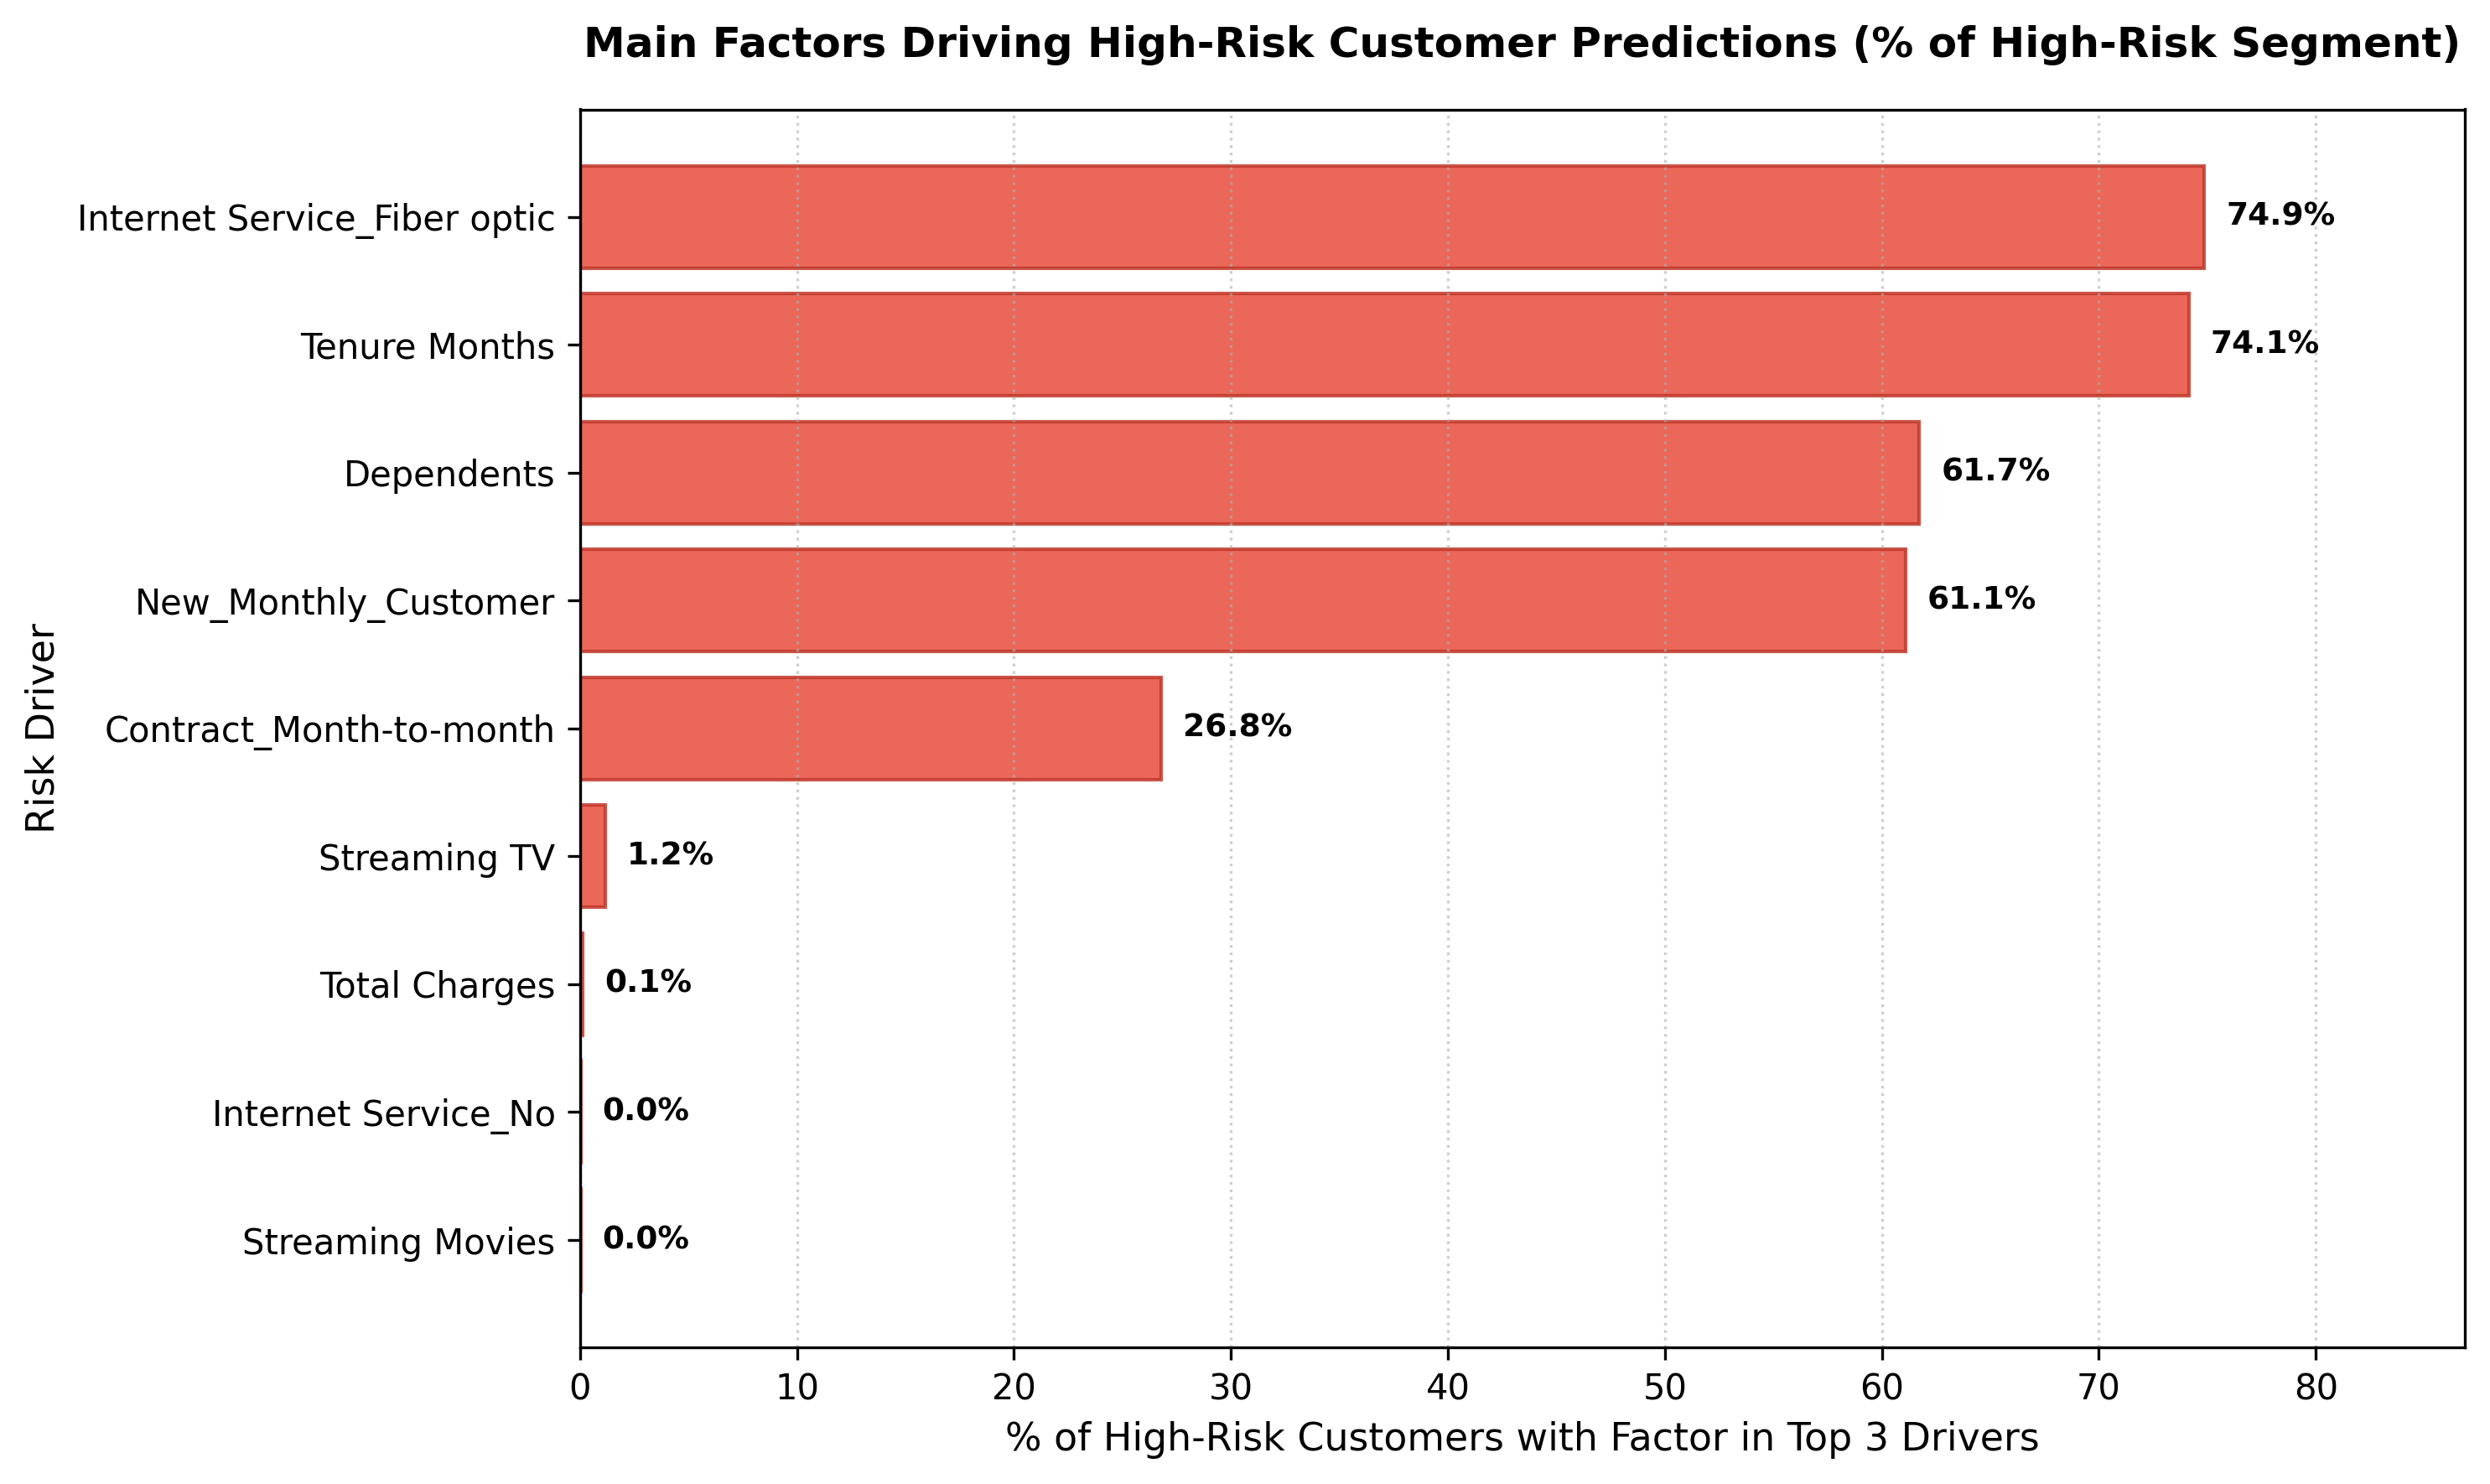

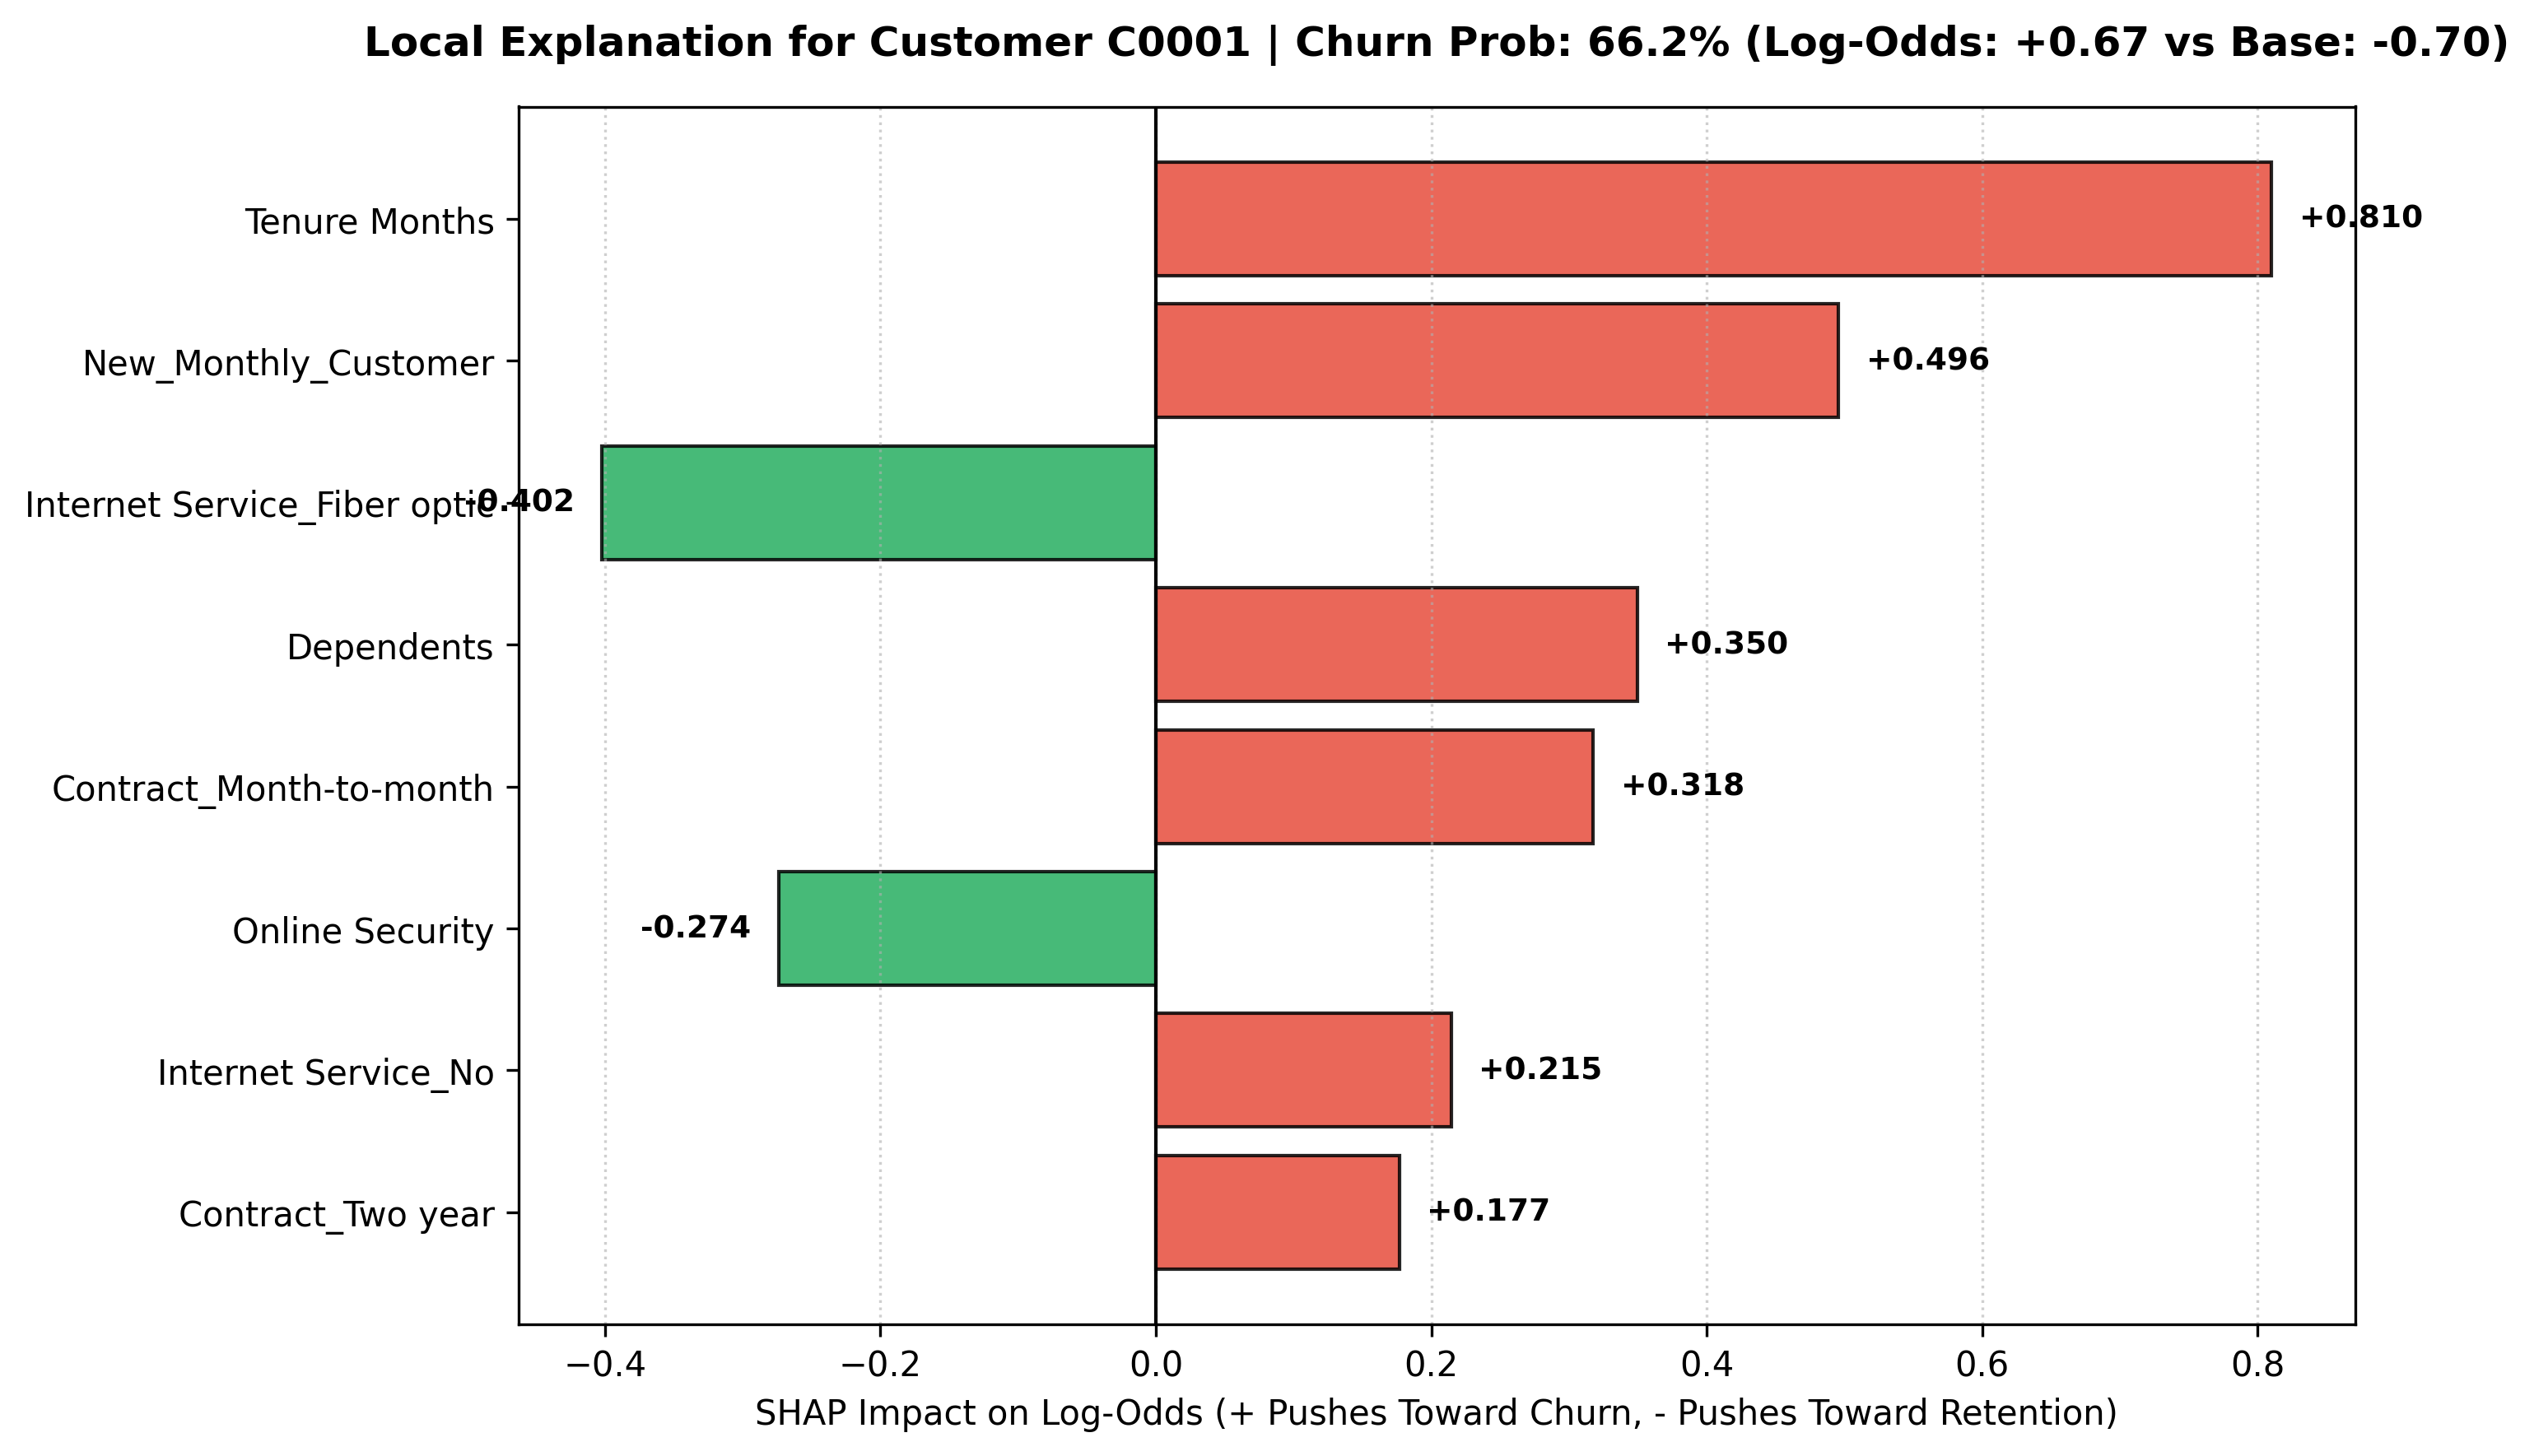

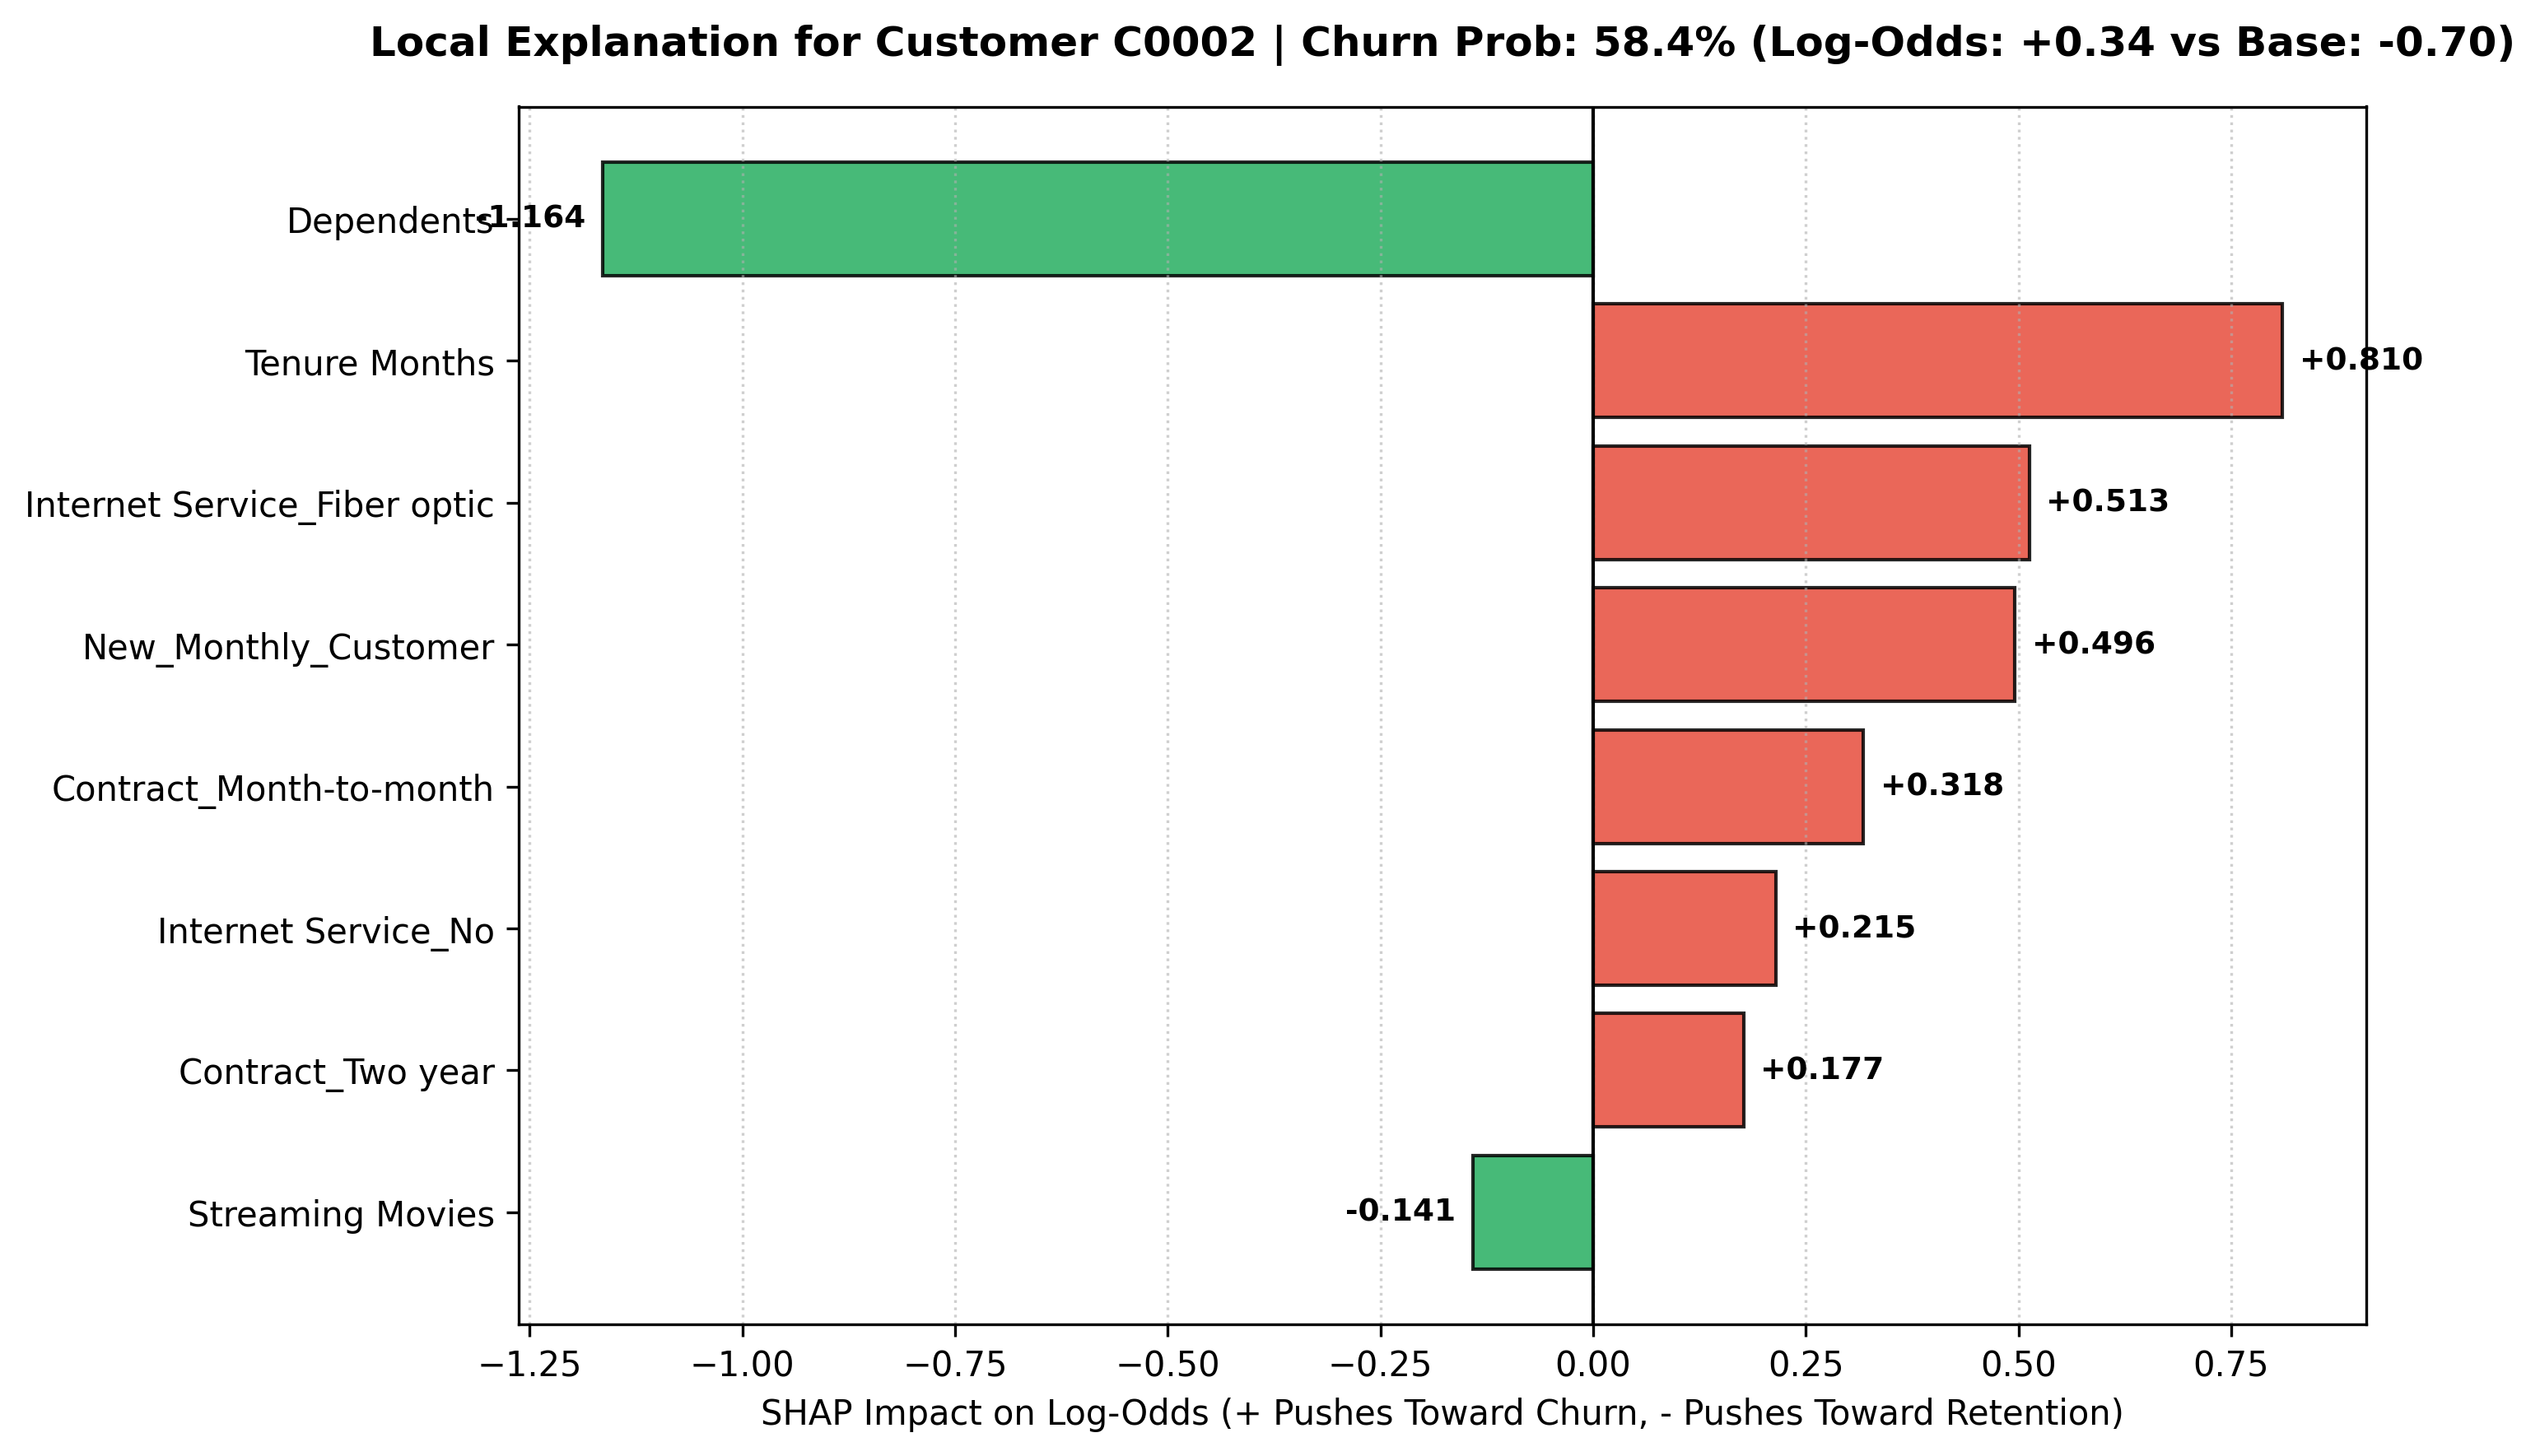

In [4]:
profiler = CustomerRiskProfiler(explainer)
scored_df = profiler.score_and_profile_dataset(df, CORE_FEATURES)
risk_summary = profiler.compute_risk_summary(scored_df, df_original=df)

print("Customer Risk Tier Distribution:")
print(risk_summary.to_string())

profiler.plot_risk_distribution(risk_summary)

high_risk_factors = profiler.analyze_high_risk_factors(scored_df)
print("Top Factors Driving High-Risk Customer Predictions:")
print(high_risk_factors.head(10).to_string())
profiler.plot_high_risk_drivers(high_risk_factors, top_n=10)

explainer.plot_waterfall(X.iloc[0], customer_id="Customer C0001", max_display=8)
explainer.plot_waterfall(X.iloc[1], customer_id="Customer C0002", max_display=8)

## Part 3: Retention Strategy Matrix & ROI Modeling (Member 3)

Retention Strategy Matrix:
            id                driver_pattern                                driver_name                                             customer_segment                                                               recommended_action                                       channel    urgency  expected_churn_reduction_pct  cost_per_customer
0       ACT_01       Contract_Month-to-month                    Month-to-Month Contract              Month-to-Month Subscribers with High Churn Risk   12/24-Month Long-Term Contract Incentive with $15/mo discount & streaming perk          In-App Notification / Email Campaign       High                          40.0               60.0
1       ACT_02  Internet Service_Fiber optic  Fiber Optic High Spend / Service Friction            Fiber Optic Users with Elevated Churn Probability     Personalized Value Plan Review + Speed Guarantee + Bundled Free Tech Support  Dedicated Account Specialist / Outbound Call       High               

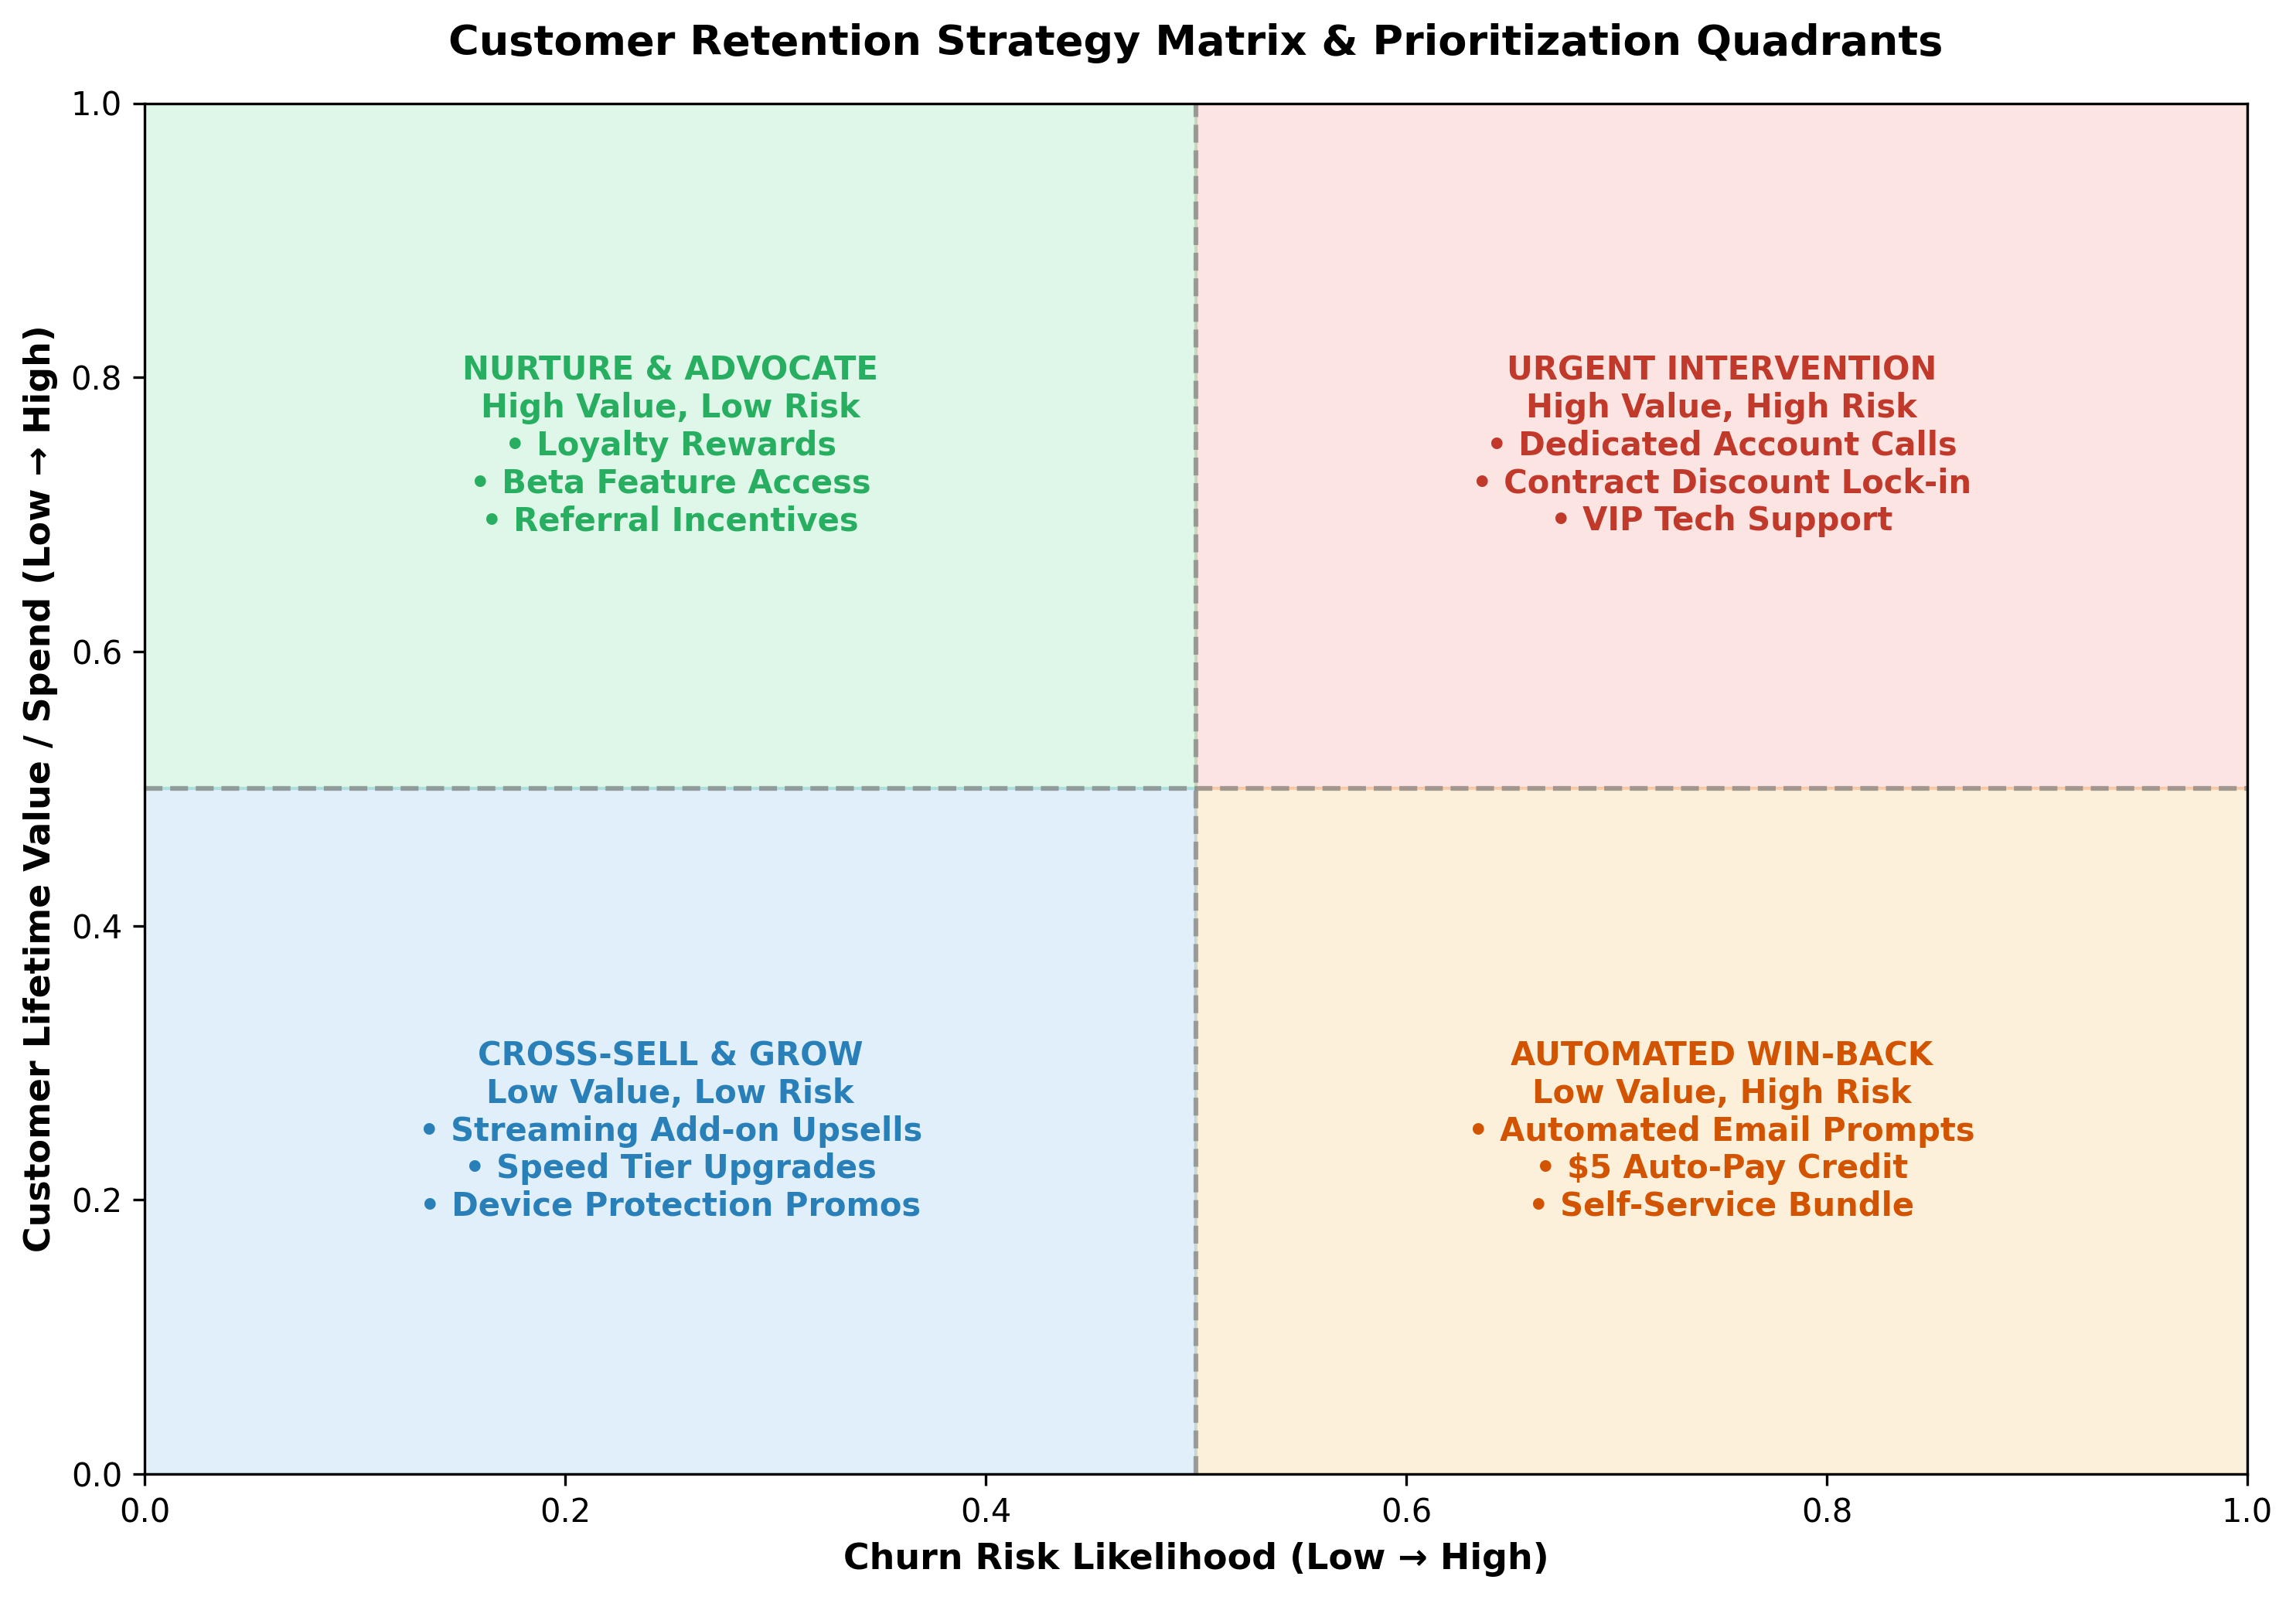

Sample Customer Explanations & Recommended Actions:
  Customer_ID  Churn_Probability Risk_Category          Primary_Churn_Driver                                Action_Name                                                            Recommended_Action
0       C0001             0.6621     High Risk                 Tenure Months          Low Tenure / Early Lifecycle Risk     First-Year Milestone Loyalty Credit + Complimentary 3-Month Speed Upgrade
1       C0002             0.5841   Medium Risk                 Tenure Months          Low Tenure / Early Lifecycle Risk     First-Year Milestone Loyalty Credit + Complimentary 3-Month Speed Upgrade
2       C0003             0.7385     High Risk                 Tenure Months          Low Tenure / Early Lifecycle Risk     First-Year Milestone Loyalty Credit + Complimentary 3-Month Speed Upgrade
3       C0004             0.4611   Medium Risk  Internet Service_Fiber optic  Fiber Optic High Spend / Service Friction  Personalized Value Plan Review + Sp

In [5]:
retention_engine = RetentionStrategyEngine()
strategy_matrix = retention_engine.get_strategy_matrix()
print("Retention Strategy Matrix:")
print(strategy_matrix.to_string())

retention_engine.plot_strategy_quadrant()

customer_explanations = retention_engine.enhance_customer_explanations(scored_df)
print("Sample Customer Explanations & Recommended Actions:")
print(customer_explanations[["Customer_ID", "Churn_Probability", "Risk_Category", "Primary_Churn_Driver", "Action_Name", "Recommended_Action"]].head(10).to_string())

roi_df = retention_engine.simulate_retention_campaign_roi(customer_explanations)
print("Retention Campaign Financial ROI Simulation:")
print(roi_df.to_string())